# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')


df.loc[df['Age'] < 16, 'Age_cat'] = 'Child'
df.loc[(df['Age'] >= 16) & (df['Age'] < 55), 'Age_cat'] = 'Adult'
df.loc[df['Age'] >= 55, 'Age_cat'] = 'Senior'


df.loc[df['Fare'] <= 15, 'Fare_cat'] = 'Low Fare'
df.loc[(df['Fare'] > 15) & (df['Fare'] <= 50), 'Fare_cat'] = 'Medium Fare'
df.loc[df['Fare'] > 50, 'Fare_cat'] = 'High Fare'


df['Family_Size'] = df['Parch'] + df['SibSp']
df.loc[df['Family_Size'] > 0, 'Companions'] = 'With Family'
df.loc[df['Family_Size'] == 0, 'Companions'] = 'Alone'

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_cat,Fare_cat,Family_Size,Companions
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult,Low Fare,1,With Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,High Fare,1,With Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,Low Fare,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,High Fare,1,With Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,Low Fare,0,Alone


In [8]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Feature Engineering Logic:

Age: I broke Age down into Child (< 16), Adult (16-54), and Senior (55+). Basically, the "women and children first" rule means kids got priority, while seniors probably had a much harder time physically making it to the lifeboats during the chaos.

Fare: Fares were split into Low Fare (<= $15), Medium Fare ($15-$50), and High Fare (> $50). These breakpoints map pretty well to the average 3rd, 2nd, and 1st class ticket prices, so it's a solid proxy for status.

Companions: To figure out if someone was traveling solo or with a party, I just added Parch and SibSp together into Family_Size. If the total is 0, they're running Alone. If it's greater than 0, they're With Family.

<Axes: title={'center': 'Survival by Sex'}, xlabel='Sex', ylabel='Percentage'>

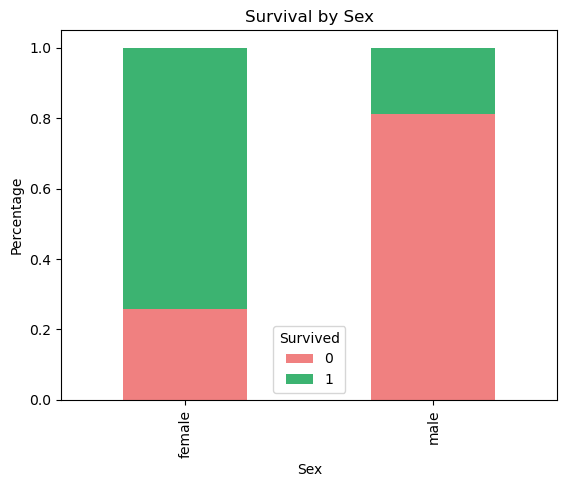

In [2]:
pd.crosstab(df['Sex'], df['Survived'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], title='Survival by Sex', ylabel='Percentage')

<Axes: title={'center': 'Survival by Passenger Class'}, xlabel='Pclass', ylabel='Percentage'>

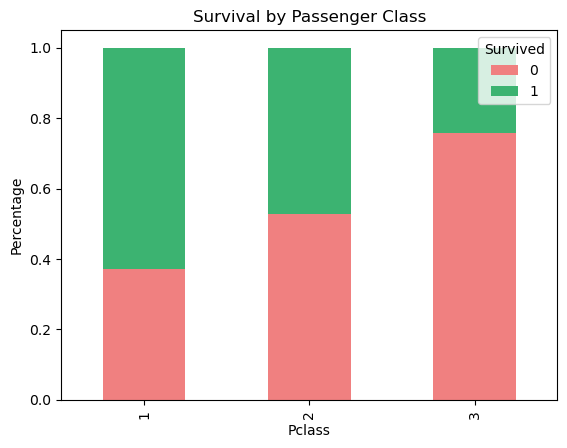

In [3]:
pd.crosstab(df['Pclass'], df['Survived'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], title='Survival by Passenger Class', ylabel='Percentage')

<Axes: title={'center': 'Survival by Age Category'}, xlabel='Age_cat', ylabel='Percentage'>

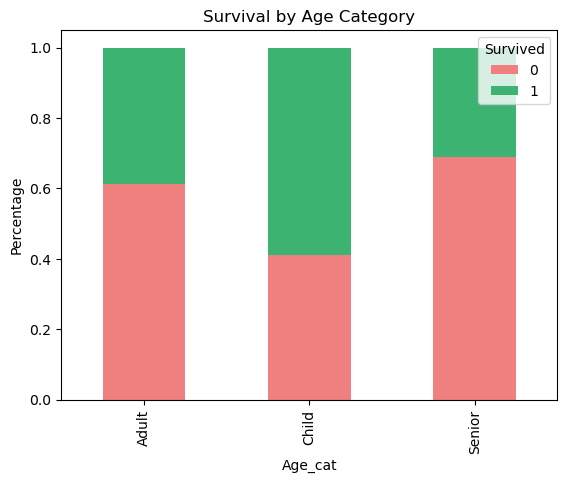

In [4]:
pd.crosstab(df['Age_cat'], df['Survived'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], title='Survival by Age Category', ylabel='Percentage')

<Axes: title={'center': 'Survival by Fare Paid'}, xlabel='Fare_cat', ylabel='Percentage'>

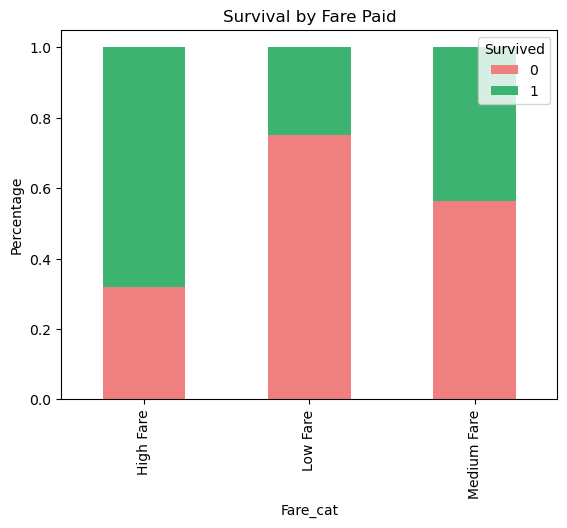

In [5]:
pd.crosstab(df['Fare_cat'], df['Survived'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], title='Survival by Fare Paid', ylabel='Percentage')

<Axes: title={'center': 'Survival by Port of Departure'}, xlabel='Embarked', ylabel='Percentage'>

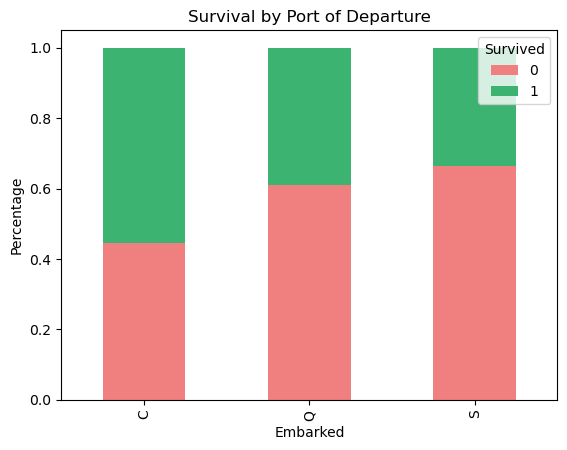

In [6]:
pd.crosstab(df['Embarked'], df['Survived'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'], title='Survival by Port of Departure', ylabel='Percentage')

In [7]:
most_likely = df[(df['Sex'] == 'female') & (df['Pclass'] == 1) & (df['Companions'] == 'With Family') & (df['Fare_cat'] == 'High Fare') & (df['Embarked'] == 'C')]
print("Most Likely to Survive Match:")
display(most_likely[['Name', 'Age_cat', 'Fare_cat', 'Companions']].head(1))

least_likely = df[(df['Sex'] == 'male') & (df['Pclass'] == 3) & (df['Companions'] == 'Alone') & (df['Fare_cat'] == 'Low Fare') & (df['Embarked'] == 'S') & (df['Age_cat'] == 'Adult')]
print("\nLeast Likely to Survive Match:")
display(least_likely[['Name', 'Age_cat', 'Fare_cat', 'Companions']].head(1))

Most Likely to Survive Match:


,Name,Age_cat,Fare_cat,Companions
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Adult,High Fare,With Family



Least Likely to Survive Match:


,Name,Age_cat,Fare_cat,Companions
4,"Allen, Mr. William Henry",Adult,Low Fare,Alone


Character Profile 1: The "Most Likely to Survive" Build
Looking at the charts, if you wanted to min-max your chances of surviving the Titanic, this is the ultimate meta build:

Sex: Female (The survival rate difference here is massive compared to guys).

Passenger Class: 1st Class (Highest priority for lifeboats).

Age: Child/Adult (Kids and women got the main priority).

Fare: High Fare (Paid for that VIP lifeboat access).

Companions: With Family (Running with a party definitely boosted your survival odds).

Embarked: C (Cherbourg departures had the best RNG for survival).

Character Profile 2: The "Least Likely to Survive" Build
On the flip side, a passenger with this profile essentially rolled a Nat 1 on their survival check:

Sex: Male.

Passenger Class: 3rd Class.

Age: Adult.

Fare: Low Fare.

Companions: Alone (Running solo in 3rd class was brutal).

Embarked: S (Southampton departures had the lowest survival percentage).

Historical Facts for Mr. Cameron:
Here are two real passengers pulled from Encyclopedia Titanica that perfectly match those profiles:

1. The Survivor Match: Astor, Mrs. John Jacob (Madeleine Talmadge Force)

Interesting Fact: Madeleine Astor is a perfect match for our 1st Class female profile embarking from Cherbourg. She was 18 and actually pregnant during the trip. She made it off the ship in Lifeboat 4, but her husband (who was literally the wealthiest guy on the Titanic) didn't survive.

2. The Doomed Match: Allen, Mr. William Henry

Interesting Fact: William Henry Allen fits the 3rd class adult male traveling alone profile perfectly. He was a 35-year-old toolmaker heading to New York to find work. Like the vast majority of solo guys in 3rd class, he was lost in the disaster and his body was never recovered.